<a href="https://colab.research.google.com/github/Lawson-Dong/SINDy_code_reproduction/blob/main/LASSO%2CSTLS%2CL2_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training data shape: (1000, 3), Time steps: 1000
Test data shape: (1600, 3), Time steps: 1600
Library size: 20 features


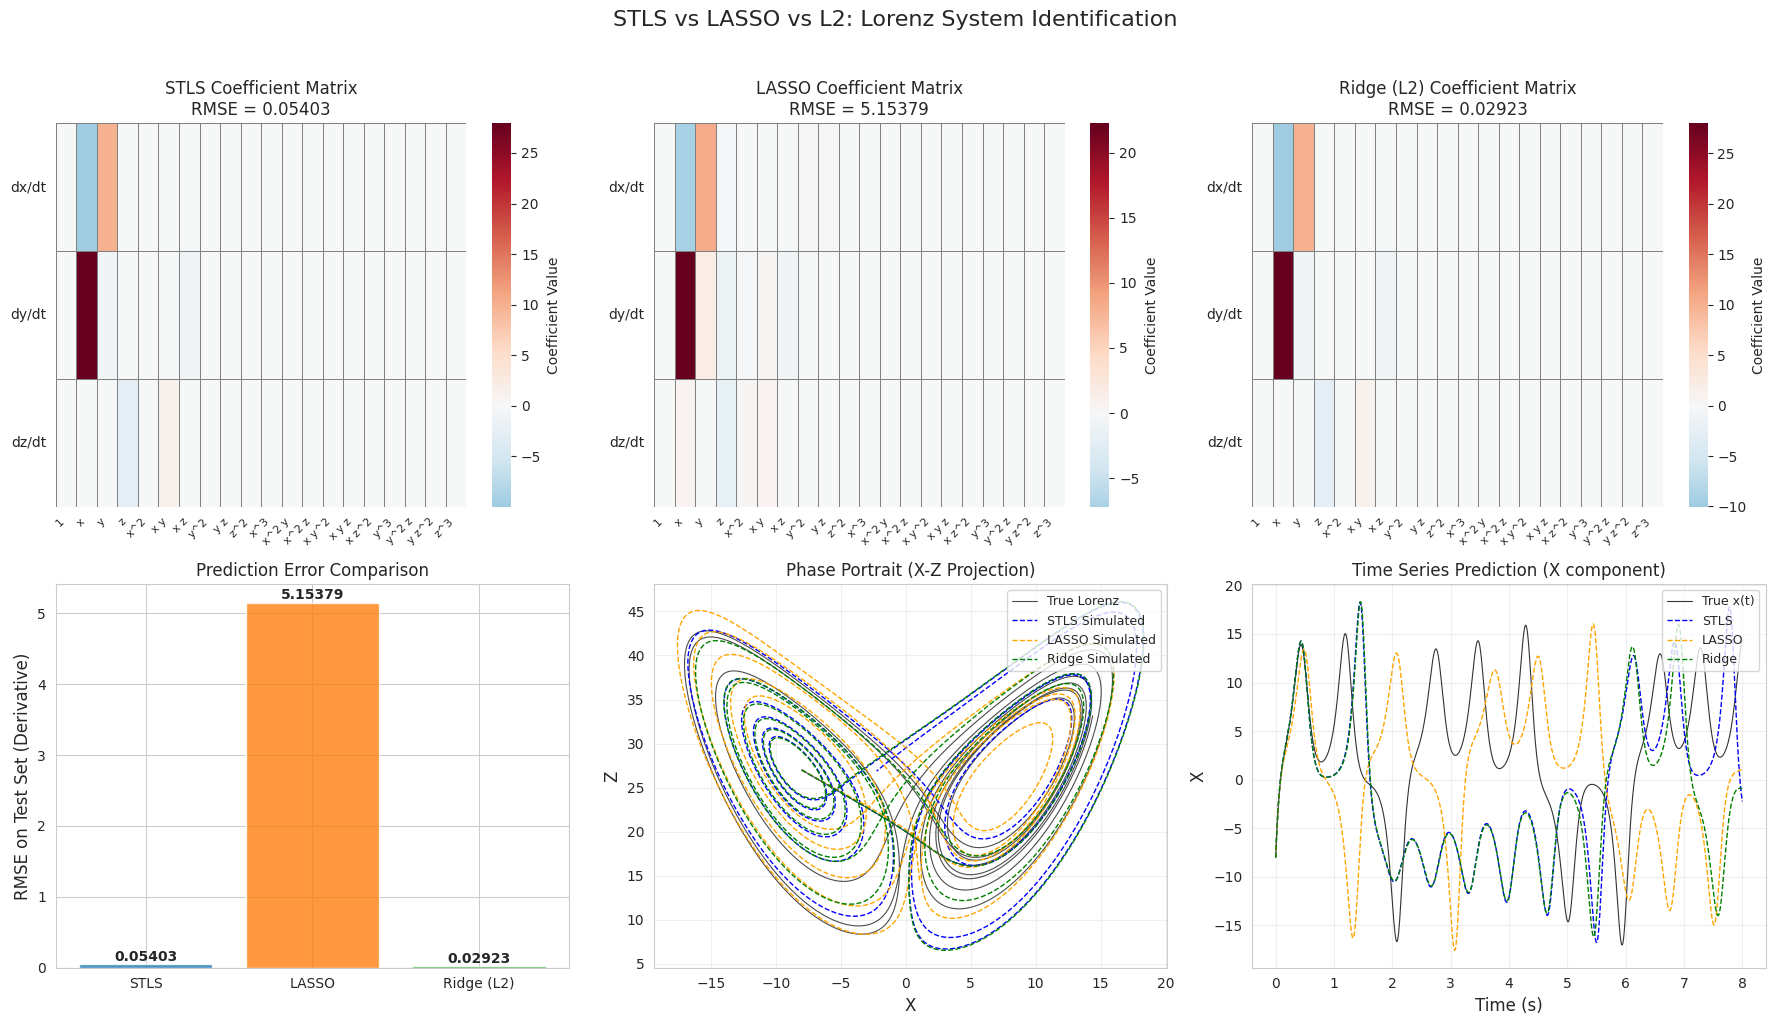


IDENTIFIED EQUATIONS (True Lorenz: dx = 10(y-x), dy = x(28-z)-y, dz = xy - 2.666z)

--- STLS (SINDy) ---
dx/dt = -9.996*x + 9.996*y
dy/dt = 27.956*x - 0.992*y - 0.999*x z
dz/dt = -2.665*z + 0.999*x y

--- LASSO ---
dx/dt = -7.184*x + 8.422*y - 0.239*z - 0.021*x^2 - 0.114*x y - 0.120*x z + 0.065*y^2 + 0.069*y z + 0.021*z^2 + 0.006*x^3 - 0.006*x^2 y + 0.003*x^2 z + 0.001*x y^2 + 0.001*x y z + 0.001*x z^2 + 0.000*y^3 - 0.001*y^2 z - 0.001*y z^2 - 0.001*z^3
dy/dt = 22.263*x + 1.650*y - 0.983*z - 0.170*x^2 + 0.194*x y - 0.677*x z - 0.048*y^2 - 0.101*y z + 0.038*z^2 - 0.001*x^3 + 0.015*x^2 y + 0.002*x^2 z - 0.010*x y^2 - 0.003*x y z - 0.004*x z^2 + 0.001*y^3 + 0.000*y^2 z - 0.000*y z^2 - 0.000*z^3
dz/dt = 0.545*x - 0.063*y - 1.739*z + 0.377*x^2 + 0.716*x y - 0.047*x z + 0.053*y^2 + 0.001*y z - 0.050*z^2 + 0.004*x^3 - 0.011*x^2 y - 0.011*x^2 z + 0.010*x y^2 + 0.009*x y z + 0.001*x z^2 - 0.003*y^3 - 0.003*y^2 z + 0.000*y z^2 + 0.001*z^3

--- Ridge (L2) ---
dx/dt = -10.014*x + 10.010*y + 0.001

In [3]:
# -*- coding: utf-8 -*-
"""
Comparison of Sparse Regression Methods for Lorenz System Identification
Environment: Google Colab
Methods: STLS (SINDy), LASSO (L1), Ridge (L2)
"""

# Install pysindy if not already installed
!pip install pysindy scikit-learn matplotlib seaborn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error
from pysindy import SINDy
from pysindy.optimizers import STLSQ
from pysindy.feature_library import PolynomialLibrary
from pysindy.differentiation import FiniteDifference

# Set random seed for reproducibility
np.random.seed(42)
sns.set_style("whitegrid")

# ------------------------------------------------------------
# 1. Generate Lorenz System Data
# ------------------------------------------------------------
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    """
    Lorenz system ODEs.
    dx/dt = sigma * (y - x)
    dy/dt = x * (rho - z) - y
    dz/dt = x * y - beta * z
    """
    x, y, z = state
    return [sigma * (y - x),
            x * (rho - z) - y,
            x * y - beta * z]

# Time span and initial condition
dt = 0.005
t_train = np.arange(0, 5, dt)   # Training data: 0 to 5 seconds
t_test = np.arange(0, 8, dt)    # Test data for extrapolation: 0 to 8 seconds

x0 = [-8, 7, 27]  # Typical chaotic initial condition

# Solve ODE for training set
sol_train = solve_ivp(lorenz, [t_train[0], t_train[-1]], x0, t_eval=t_train, rtol=1e-8, atol=1e-8)
X_train = sol_train.y.T  # Shape: (n_samples, 3)
t_train_span = sol_train.t

# Solve ODE for test set (longer trajectory for RMSE extrapolation check)
sol_test = solve_ivp(lorenz, [t_test[0], t_test[-1]], x0, t_eval=t_test, rtol=1e-8, atol=1e-8)
X_test = sol_test.y.T
t_test_span = sol_test.t

print(f"Training data shape: {X_train.shape}, Time steps: {len(t_train)}")
print(f"Test data shape: {X_test.shape}, Time steps: {len(t_test)}")

# ------------------------------------------------------------
# 2. Prepare Derivative Data (dX/dt) and Feature Library
# ------------------------------------------------------------
# Compute derivatives using finite difference (5-point stencil)
fd = FiniteDifference(order=2)
X_dot_train = fd._differentiate(X_train, dt)
X_dot_test = fd._differentiate(X_test, dt)

# Generate polynomial feature library (up to 3rd order)
# This mimics the typical SINDy library: [1, x, y, z, x^2, x*y, ..., z^3]
lib = PolynomialLibrary(degree=3)
lib.fit(X_train)
Theta_train = lib.transform(X_train)  # Candidate function library
Theta_test = lib.transform(X_test)

feature_names = lib.get_feature_names(input_features=['x', 'y', 'z'])
print(f"Library size: {Theta_train.shape[1]} features")

# ------------------------------------------------------------
# 3. Fit Models: STLS (SINDy), LASSO, Ridge (L2)
# ------------------------------------------------------------
# Helper function to calculate RMSE
def compute_rmse(true_dot, pred_dot):
    # Convert to numpy arrays if needed
    true_dot = np.asarray(true_dot)
    pred_dot = np.asarray(pred_dot)
    return np.sqrt(mean_squared_error(true_dot, pred_dot))

# Dictionary to store results
results = {}

# --- Method 1: STLS (SINDy default) ---
# STLS with threshold = 0.1 (sparsity knob) and L2 regularization alpha = 0.05
optimizer = STLSQ(threshold=0.1, alpha=0.05, max_iter=20)

# FIXED: Removed 'quiet' argument and use 'verbose' instead (or omit entirely)
model_stls = SINDy(
    optimizer=optimizer,
    feature_library=lib,
    differentiation_method=fd
)
# In newer PySINDy versions, 'quiet' is replaced by 'verbose'
# Setting verbose=False is equivalent to quiet=True
try:
    model_stls.fit(X_train, t=t_train_span, verbose=False)
except TypeError:
    # Fallback for older versions
    model_stls.fit(X_train, t=t_train_span)

# Get coefficients and convert to numpy array to avoid AxesArray issues
Xi_stls = np.asarray(model_stls.coefficients().T)  # Transpose to (features, targets)

# Predict derivatives on test set
X_dot_pred_stls = np.asarray(model_stls.predict(X_test))

# Compute RMSE
rmse_stls = compute_rmse(X_dot_test, X_dot_pred_stls)
results['STLS'] = {'Xi': Xi_stls, 'RMSE': rmse_stls}

# --- Method 2: LASSO (L1 regularization) ---
# We fit a separate LASSO model for each state variable (x, y, z)
Xi_lasso = np.zeros_like(Xi_stls)
lasso_alphas = [1e-5, 1e-5, 1e-5] # Tuned alpha for each dimension to balance sparsity

for i in range(3):
    lasso = Lasso(alpha=lasso_alphas[i], max_iter=10000, tol=1e-4)
    lasso.fit(Theta_train, X_dot_train[:, i])
    Xi_lasso[:, i] = lasso.coef_

# Predict derivatives
X_dot_pred_lasso = Theta_test @ Xi_lasso

rmse_lasso = compute_rmse(X_dot_test, X_dot_pred_lasso)
results['LASSO'] = {'Xi': Xi_lasso, 'RMSE': rmse_lasso}

# --- Method 3: Ridge Regression (L2 only, no sparsity) ---
Xi_ridge = np.zeros_like(Xi_stls)
ridge_alpha = 0.01  # Small L2 penalty for numerical stability

for i in range(3):
    ridge = Ridge(alpha=ridge_alpha)
    ridge.fit(Theta_train, X_dot_train[:, i])
    Xi_ridge[:, i] = ridge.coef_

X_dot_pred_ridge = Theta_test @ Xi_ridge
rmse_ridge = compute_rmse(X_dot_test, X_dot_pred_ridge)
results['Ridge (L2)'] = {'Xi': Xi_ridge, 'RMSE': rmse_ridge}

# ------------------------------------------------------------
# 4. Visualization and Comparison
# ------------------------------------------------------------
fig = plt.figure(figsize=(18, 10))

# --- Subplot 1: Coefficient Matrices (Sparsity Pattern) ---
methods = ['STLS', 'LASSO', 'Ridge (L2)']
for idx, method in enumerate(methods):
    ax = fig.add_subplot(2, 3, idx + 1)
    Xi = results[method]['Xi']

    # Plot heatmap
    sns.heatmap(Xi.T, ax=ax, cmap='RdBu_r', center=0,
                xticklabels=feature_names, yticklabels=['dx/dt', 'dy/dt', 'dz/dt'],
                cbar_kws={'label': 'Coefficient Value'}, linewidths=0.5, linecolor='gray')
    ax.set_title(f'{method} Coefficient Matrix\nRMSE = {results[method]["RMSE"]:.5f}', fontsize=12)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=10)

# --- Subplot 4: Bar plot of RMSE comparison ---
ax4 = fig.add_subplot(2, 3, 4)
rmse_values = [results[m]['RMSE'] for m in methods]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax4.bar(methods, rmse_values, color=colors, alpha=0.8)
ax4.set_ylabel('RMSE on Test Set (Derivative)', fontsize=12)
ax4.set_title('Prediction Error Comparison', fontsize=12)
# Add value labels on bars
for bar, val in zip(bars, rmse_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.5f}', ha='center', va='bottom', fontweight='bold')

# --- Subplot 5 & 6: Trajectory Prediction Comparison (Simulated from learned derivatives) ---
def simulate_trajectory(Xi, x0, t_span, dt, lib):
    """
    Simple Euler integration using predicted derivatives to see long-term behavior.
    FIXED: Convert all inputs to numpy arrays to avoid AxesArray compatibility issues.
    """
    # Ensure inputs are numpy arrays
    Xi = np.asarray(Xi)
    x0 = np.asarray(x0)

    X_sim = np.zeros((len(t_span), 3))
    X_sim[0] = x0

    for i in range(1, len(t_span)):
        # Get current state as numpy array
        current_state = np.asarray(X_sim[i-1:i, :])

        # Build library for current state and convert to numpy
        theta = np.asarray(lib.transform(current_state))

        # Predicted derivative using numpy arrays
        dx = np.asarray(theta @ Xi)

        # Update state
        X_sim[i] = X_sim[i-1] + dt * dx.flatten()

    return X_sim

# Simulate for 8 seconds (test set span)
X_sim_stls = simulate_trajectory(Xi_stls, x0, t_test_span, dt, lib)
X_sim_lasso = simulate_trajectory(Xi_lasso, x0, t_test_span, dt, lib)
X_sim_ridge = simulate_trajectory(Xi_ridge, x0, t_test_span, dt, lib)

# Plot Phase Portrait (X vs Z projection) to visualize chaotic attractor capture
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(X_test[:, 0], X_test[:, 2], 'k-', linewidth=0.8, alpha=0.7, label='True Lorenz')
ax5.plot(X_sim_stls[:, 0], X_sim_stls[:, 2], 'b--', linewidth=1.0, label='STLS Simulated')
ax5.plot(X_sim_lasso[:, 0], X_sim_lasso[:, 2], 'orange', linestyle='--', linewidth=1.0, label='LASSO Simulated')
ax5.plot(X_sim_ridge[:, 0], X_sim_ridge[:, 2], 'g--', linewidth=1.0, label='Ridge Simulated')
ax5.set_xlabel('X', fontsize=12)
ax5.set_ylabel('Z', fontsize=12)
ax5.set_title('Phase Portrait (X-Z Projection)', fontsize=12)
ax5.legend(loc='upper right', fontsize=9)
ax5.grid(True, alpha=0.3)

# Plot Time Series for X component to see divergence
ax6 = fig.add_subplot(2, 3, 6)
ax6.plot(t_test_span, X_test[:, 0], 'k-', linewidth=0.8, alpha=0.8, label='True x(t)')
ax6.plot(t_test_span, X_sim_stls[:, 0], 'b--', linewidth=1.0, label='STLS')
ax6.plot(t_test_span, X_sim_lasso[:, 0], 'orange', linestyle='--', linewidth=1.0, label='LASSO')
ax6.plot(t_test_span, X_sim_ridge[:, 0], 'g--', linewidth=1.0, label='Ridge')
ax6.set_xlabel('Time (s)', fontsize=12)
ax6.set_ylabel('X', fontsize=12)
ax6.set_title('Time Series Prediction (X component)', fontsize=12)
ax6.legend(loc='upper right', fontsize=9)
ax6.grid(True, alpha=0.3)

plt.suptitle('STLS vs LASSO vs L2: Lorenz System Identification', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Print Identified Equations
# ------------------------------------------------------------
print("\n" + "="*60)
print("IDENTIFIED EQUATIONS (True Lorenz: dx = 10(y-x), dy = x(28-z)-y, dz = xy - 2.666z)")
print("="*60)

def print_equation(Xi, feature_names, method_name):
    print(f"\n--- {method_name} ---")
    for i, target in enumerate(['x', 'y', 'z']):
        terms = []
        for j, name in enumerate(feature_names):
            coef = Xi[j, i]
            if abs(coef) > 1e-4:  # Only print non-zero terms
                if name == '1':
                    terms.append(f"{coef:.3f}")
                else:
                    terms.append(f"{coef:.3f}*{name}")
        eq = " + ".join(terms).replace("+ -", "- ")
        if eq == "":
            eq = "0"
        print(f"d{target}/dt = {eq}")

print_equation(Xi_stls, feature_names, "STLS (SINDy)")
print_equation(Xi_lasso, feature_names, "LASSO")
print_equation(Xi_ridge, feature_names, "Ridge (L2)")

print(f"\n--- Final RMSE Comparison on Test Derivatives ---")
for method in methods:
    print(f"{method:12s}: {results[method]['RMSE']:.6f}")